# Handwritten Digit Recognition — Computer Vision Pipeline

**Author:** Oli Bakala  
**Dataset:** 1,250 handwritten digit images (10 classes × 125 images)  
**Model:** Convolutional Neural Network (CNN)  
**Deployment:** Streamlit

---

## Pipeline Overview

| Stage | Description |
|-------|-------------|
| **1** | Environment Setup & Library Imports |
| **2** | Dataset Audit |
| **3** | Visual Inspection |
| **4** | Preprocessing Pipeline |
| **5** | Dataset Processing |
| **6** | Train / Validation / Test Split |
| **7** | Data Augmentation |
| **8** | CNN Architecture |
| **9** | Model Training |
| **10** | Evaluation & Error Analysis |
| **11** | Model Export |
| **12** | Conclusion |

---

## Stage 1 — Environment Setup & Library Imports

In [2]:
# ============================================================
# STAGE 1 — ENVIRONMENT SETUP & LIBRARY IMPORTS
# ============================================================

# ------------------------------------------------------------
# 1.1  Standard library
# ------------------------------------------------------------
import os
import random
from pathlib import Path

# ------------------------------------------------------------
# 1.2  Data handling
# ------------------------------------------------------------
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1.3  Image processing
# ------------------------------------------------------------
import cv2
from PIL import Image

# ------------------------------------------------------------
# 1.4  Visualisation
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ------------------------------------------------------------
# 1.5  Machine learning
# ------------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

# ------------------------------------------------------------
# 1.6  Google Drive (Colab only)
# ------------------------------------------------------------
from google.colab import drive

drive.mount("/content/drive")

# ------------------------------------------------------------
# 1.7  Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# 1.8  Global constants
# ------------------------------------------------------------
DATASET_DIR        = Path("/content/drive/MyDrive/dataset_b")
BEST_MODEL_PATH    = "/content/drive/MyDrive/handwritten_digit_cnn.keras"
TARGET_SIZE        = 32          # CNN input: 32 × 32 pixels
NUM_CLASSES        = 10
CLASSES            = [str(i) for i in range(NUM_CLASSES)]
IMAGES_PER_CLASS   = 125
VALID_EXTENSIONS   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("✓ All libraries imported")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  OpenCV      : {cv2.__version__}")
print(f"  Seed        : {SEED}")
print(f"  Dataset dir : {DATASET_DIR}")

Mounted at /content/drive
✓ All libraries imported
  TensorFlow  : 2.20.0
  OpenCV      : 4.14.0
  Seed        : 42
  Dataset dir : /content/drive/MyDrive/dataset_b


---
## Stage 2 — Dataset Audit

Before any modelling we verify that the dataset is structurally sound:
- All 10 class folders exist
- Each folder contains exactly 125 images
- No corrupted / unreadable files
- Image dimensions and colour modes are recorded

In [3]:
# ============================================================
# STAGE 2.1 — DIRECTORY & CLASS VERIFICATION
# ============================================================

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATASET_DIR}\n"
        "Place 'dataset_b' directly inside Google Drive → MyDrive."
    )

class_folders = sorted(
    [p.name for p in DATASET_DIR.iterdir() if p.is_dir()]
)

missing_classes = [c for c in CLASSES if c not in class_folders]
extra_classes   = [c for c in class_folders if c not in CLASSES]

print("=" * 60)
print("CLASS FOLDERS")
print("=" * 60)
print(f"Found   : {class_folders}")
print(f"Missing : {missing_classes if missing_classes else 'none'}")
print(f"Extra   : {extra_classes   if extra_classes   else 'none'}")

CLASS FOLDERS
Found   : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Missing : none
Extra   : none


In [4]:
# ============================================================
# STAGE 2.2 — BUILD FILE INDEX
# ============================================================

records = []
for cls in CLASSES:
    cls_dir = DATASET_DIR / cls
    if not cls_dir.exists():
        continue
    for p in sorted(cls_dir.iterdir()):
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
            records.append(
                {"filepath": str(p), "filename": p.name, "label": int(cls)}
            )

df = pd.DataFrame(records)

class_counts = df["label"].value_counts().sort_index()

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
for digit in range(NUM_CLASSES):
    count  = class_counts.get(digit, 0)
    status = "✓" if count == IMAGES_PER_CLASS else "⚠"
    print(f"  {status} Digit {digit}: {count:>4} images")

print()
print(f"Total images : {len(df)} (expected {NUM_CLASSES * IMAGES_PER_CLASS})")

CLASS DISTRIBUTION
  ✓ Digit 0:  125 images
  ✓ Digit 1:  125 images
  ✓ Digit 2:  125 images
  ✓ Digit 3:  125 images
  ✓ Digit 4:  125 images
  ✓ Digit 5:  125 images
  ✓ Digit 6:  125 images
  ✓ Digit 7:  125 images
  ✓ Digit 8:  125 images
  ✓ Digit 9:  125 images

Total images : 1250 (expected 1250)


In [5]:
# ============================================================
# STAGE 2.3 — IMAGE INTEGRITY & DIMENSION CHECK
# ============================================================

bad_images  = []
image_info  = []

for _, row in df.iterrows():
    path = Path(row["filepath"])
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            image_info.append(
                {
                    "filepath" : str(path),
                    "label"    : int(row["label"]),
                    "width"    : img.width,
                    "height"   : img.height,
                    "mode"     : img.mode,
                    "format"   : img.format,
                }
            )
    except Exception as exc:
        bad_images.append({"filepath": str(path), "error": str(exc)})

info_df = pd.DataFrame(image_info)

print("=" * 60)
print("IMAGE INTEGRITY")
print("=" * 60)
print(f"  Checked  : {len(df)}")
print(f"  Valid    : {len(image_info)}")
print(f"  Corrupt  : {len(bad_images)}")

if not info_df.empty:
    print()
    print("=" * 60)
    print("IMAGE DIMENSIONS (pixels)")
    print("=" * 60)
    print(f"  Width  — min {info_df['width'].min():>5}  "
          f"max {info_df['width'].max():>5}  "
          f"mean {info_df['width'].mean():>8.1f}")
    print(f"  Height — min {info_df['height'].min():>5}  "
          f"max {info_df['height'].max():>5}  "
          f"mean {info_df['height'].mean():>8.1f}")
    print()
    print("Colour modes :", info_df["mode"].value_counts().to_dict())
    print("Formats      :", info_df["format"].value_counts().to_dict())

# ── Final audit flag ─────────────────────────────────────────
dataset_ok = (
    len(df) == NUM_CLASSES * IMAGES_PER_CLASS
    and len(bad_images) == 0
    and not missing_classes
    and not extra_classes
    and all(class_counts.get(d, 0) == IMAGES_PER_CLASS for d in range(NUM_CLASSES))
)
print()
print("=" * 60)
if dataset_ok:
    print("✓  DATASET AUDIT PASSED — ready for preprocessing")
else:
    print("⚠  DATASET AUDIT FAILED — review warnings above")
print("=" * 60)

IMAGE INTEGRITY
  Checked  : 1250
  Valid    : 1250
  Corrupt  : 0

IMAGE DIMENSIONS (pixels)
  Width  — min    86  max  8160  mean   1358.1
  Height — min    66  max  7550  mean   1359.9

Colour modes : {'RGB': 1250}
Formats      : {'JPEG': 1250}

✓  DATASET AUDIT PASSED — ready for preprocessing


---
## Stage 3 — Visual Inspection

Before writing a preprocessing function we examine representative images from each class to understand:
- Typical handwriting style and stroke thickness
- Background colour variation
- Image scale range
- Any problem digits (faint ink, unusual aspect ratios)

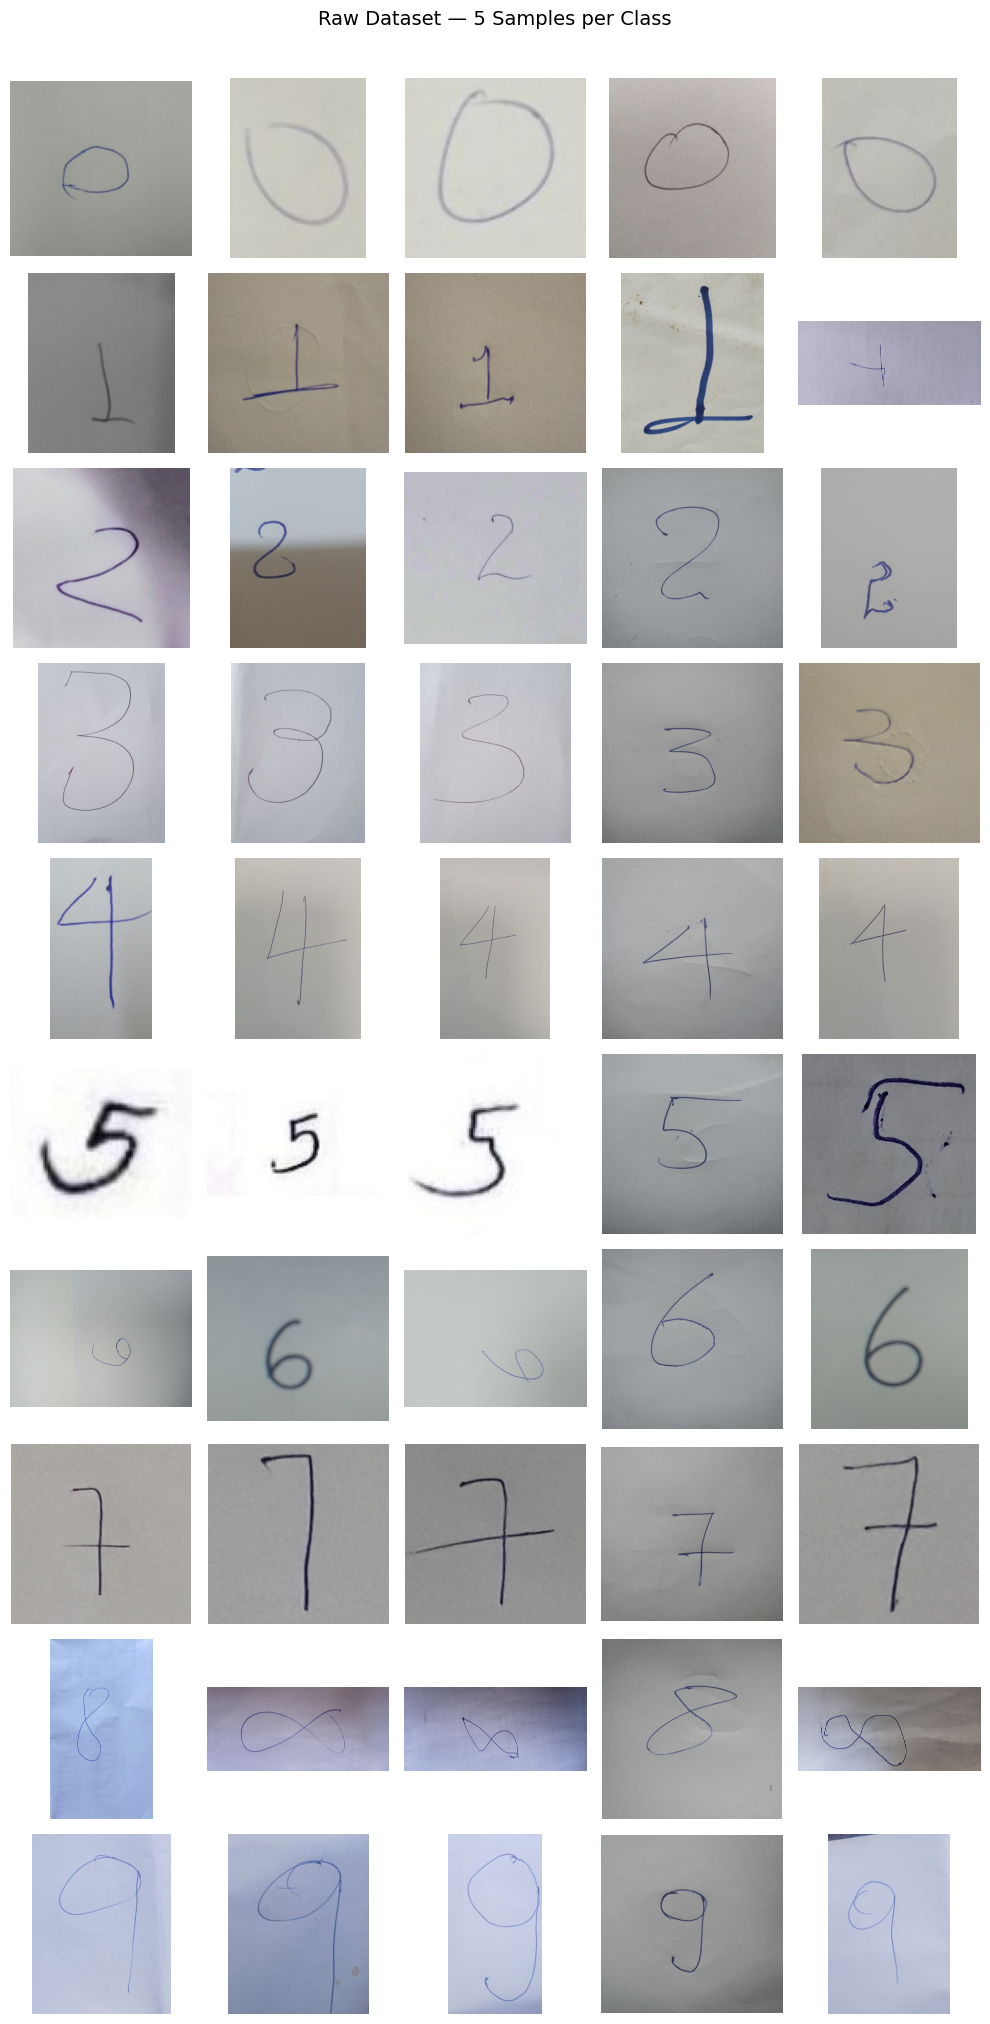

In [6]:
# ============================================================
# STAGE 3.1 — SAMPLE GRID (5 images per class)
# ============================================================

SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(
    NUM_CLASSES, SAMPLES_PER_CLASS,
    figsize=(SAMPLES_PER_CLASS * 2, NUM_CLASSES * 2)
)

for digit in range(NUM_CLASSES):
    class_rows = df[df["label"] == digit]
    samples    = class_rows.sample(
        n=min(SAMPLES_PER_CLASS, len(class_rows)),
        random_state=SEED
    )
    for col, (_, row) in enumerate(samples.iterrows()):
        ax  = axes[digit][col]
        img = Image.open(row["filepath"]).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"Digit {digit}", fontsize=10, rotation=0,
                          labelpad=40, va="center")

fig.suptitle("Raw Dataset — 5 Samples per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

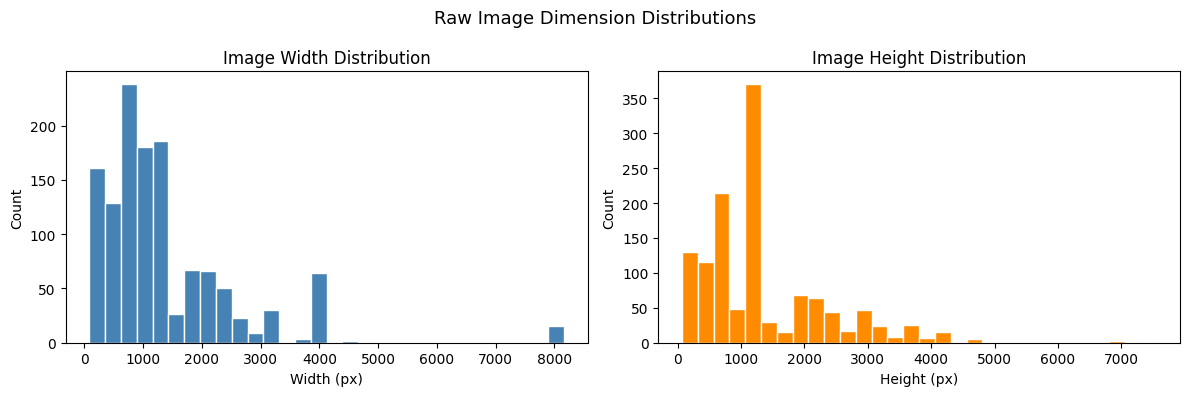

Key observations:
  • Width  range: 86 – 8160 px
  • Height range: 66 – 7550 px
  • Images are NOT uniform in size — resize is required
  • All images are RGB — grayscale conversion is required


In [7]:
# ============================================================
# STAGE 3.2 — DIMENSION DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(info_df["width"],  bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")

axes[1].hist(info_df["height"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")

plt.suptitle("Raw Image Dimension Distributions", fontsize=13)
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  • Width  range: {info_df['width'].min()} – {info_df['width'].max()} px")
print(f"  • Height range: {info_df['height'].min()} – {info_df['height'].max()} px")
print("  • Images are NOT uniform in size — resize is required")
print("  • All images are RGB — grayscale conversion is required")

---
## Stage 4 — Preprocessing Pipeline

### Design Goals

| Goal | Technique |
|------|-----------|
| Uniform input size | Resize to 32 × 32 |
| Remove colour information | Grayscale conversion |
| Robust digit detection | Three independent masks: Adaptive, Otsu, Dark-Ink |
| Candidate fusion | IoU-based bounding-box merging across masks |
| Quality scoring | Area ratio, aspect ratio, fill density, centre proximity |
| Preserve aspect ratio | Scale-then-pad on a 32 × 32 black canvas |
| Standardise pixel values | Divide by 255 → \[0, 1\] |

### Pipeline Diagram

```
Raw Image (RGB, variable size)
        ↓
Grayscale
        ↓
Three Detection Masks (run in parallel)
   ├── Adaptive Threshold (CLAHE + Gaussian C)
   ├── Otsu Threshold     (CLAHE + Otsu)
   └── Dark-Ink Detection (background subtraction)
        ↓
Candidate Extraction per mask
        ↓
Candidate Quality Scoring
   (area ratio · aspect ratio · fill density · centre proximity)
        ↓
IoU-Based Candidate Fusion  (merge overlapping boxes from different masks)
        ↓
Best Digit Region Selection  (highest fused score)
        ↓
Large Crop from Original Grayscale  (+ margin)
        ↓
Local Dark-Ink Extraction  (background subtraction on crop)
        ↓
Contrast Normalisation  (percentile stretch)
        ↓
Aspect-Ratio-Preserving Resize  (digit ≤ 28 px)
        ↓
Centre on 32 × 32 Black Canvas
        ↓
Final Contrast Stretch
        ↓
Pixel Normalisation  ÷ 255  →  [0, 1]  float32
        ↓
CNN Input  (32, 32, 1)
```

> **Why three masks?**  Single-threshold methods can miss faint digits or
> over-segment noisy backgrounds.  Running Adaptive, Otsu, and Dark-Ink
> detection independently then fusing the candidates produces more reliable
> bounding boxes across the full range of image conditions in this dataset.


In [8]:
# ============================================================
# STAGE 4.1 — V7.3 PREPROCESSING FUNCTION
#
# A multi-mask, candidate-fusion preprocessing pipeline that
# reliably isolates handwritten digits across the full range
# of image conditions present in this dataset.
#
# Key improvements over a single-threshold approach:
#   • Three independent detection masks (Adaptive, Otsu, Dark-Ink)
#   • IoU-based candidate fusion rewards multi-mask agreement
#   • Quality scoring: area · aspect · density · centre proximity
#   • Emergency dark-ink fallback — no image is ever discarded
#   • Uses sorted() instead of .sort() for tuple safety
#
# Output: float32 array (32, 32)  values in [0, 1]
#         Channel dim is added by the caller.
# ============================================================

import cv2
import numpy as np


# ── Configuration ────────────────────────────────────────────
_TARGET_SIZE      = 32
_CANVAS_SIZE      = 28     # digit drawn area within canvas
_MARGIN           = 8      # crop margin around detected bbox
_CLAHE_CLIP       = 2.0
_CLAHE_GRID       = (8, 8)
_ADAPTIVE_BLOCK   = 21
_ADAPTIVE_C       = 7
_MIN_BOX_W        = 10
_MIN_BOX_H        = 10
_MIN_AREA_RATIO   = 0.0010
_MAX_AREA_RATIO   = 0.75
_MIN_SCORE        = 0.40
_MIN_ASPECT       = 0.18
_MAX_ASPECT       = 3.50


# ── Helpers ───────────────────────────────────────────────────

def _safe_crop(img, x, y, w, h, margin=8):
    H, W = img.shape
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(W, x + w + margin)
    y2 = min(H, y + h + margin)
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        raise ValueError("Safe crop produced empty image")
    return crop


def _bbox_iou(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ix1 = max(ax, bx);  iy1 = max(ay, by)
    ix2 = min(ax+aw, bx+bw);  iy2 = min(ay+ah, by+bh)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = aw*ah + bw*bh - inter
    return inter / union if union > 0 else 0.0


def _merge_boxes(boxes):
    if not boxes:
        return None
    x1 = min(b[0]       for b in boxes)
    y1 = min(b[1]       for b in boxes)
    x2 = max(b[0]+b[2]  for b in boxes)
    y2 = max(b[1]+b[3]  for b in boxes)
    return (int(x1), int(y1), int(x2-x1), int(y2-y1))


def _candidate_quality(bbox, contour_area, image_shape):
    H, W = image_shape
    x, y, w, h = bbox
    image_area = W * H
    box_area   = w * h

    # Area score
    ratio = box_area / image_area
    if ratio < _MIN_AREA_RATIO or ratio > _MAX_AREA_RATIO:
        area_score = 0.0
    else:
        area_score = float(np.clip(np.sqrt(ratio / 0.08), 0, 1))

    # Aspect score
    aspect = w / max(h, 1)
    if aspect < _MIN_ASPECT or aspect > _MAX_ASPECT:
        aspect_score = 0.0
    elif aspect <= 1.2:
        aspect_score = float(np.clip(1.0 - abs(aspect - 0.85), 0, 1))
    else:
        aspect_score = float(np.clip(1.0 - (aspect - 1.2) / 2.3, 0, 1))

    # Density score
    density_score = float(np.clip(contour_area / max(box_area, 1) * 3.0, 0, 1))

    # Centre proximity score
    dx = ((x + w/2) - W/2) / max(W/2, 1)
    dy = ((y + h/2) - H/2) / max(H/2, 1)
    center_score = float(np.clip(1.0 - np.sqrt(dx**2 + dy**2), 0, 1))

    return float(np.clip(
        0.35*area_score + 0.25*aspect_score +
        0.20*density_score + 0.20*center_score,
        0, 1
    ))


def _extract_candidates(mask, image_shape, method_name):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    H, W = image_shape
    image_area = H * W
    candidates = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w < _MIN_BOX_W or h < _MIN_BOX_H:
            continue
        if w*h < image_area * _MIN_AREA_RATIO:
            continue
        score = _candidate_quality((x,y,w,h), cv2.contourArea(cnt), image_shape)
        if score < _MIN_SCORE:
            continue
        candidates.append({"bbox":(x,y,w,h), "score":score, "method":method_name})
    return candidates


def _create_dark_ink_mask(gray):
    bg    = cv2.GaussianBlur(gray, (0,0), sigmaX=15, sigmaY=15)
    ink   = np.maximum(bg.astype(np.float32) - gray.astype(np.float32), 0)
    nz    = ink[ink > 2]
    if len(nz) == 0:
        return None
    thr   = np.percentile(nz, 60)
    mask  = (ink >= thr).astype(np.uint8) * 255
    mask  = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
    mask  = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((2,2), np.uint8))
    return mask


def _create_otsu_mask(gray):
    clahe   = cv2.createCLAHE(clipLimit=_CLAHE_CLIP, tileGridSize=_CLAHE_GRID)
    blurred = cv2.GaussianBlur(clahe.apply(gray), (3,3), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask    = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((2,2), np.uint8))
    return mask


def _create_adaptive_mask(gray):
    clahe   = cv2.createCLAHE(clipLimit=_CLAHE_CLIP, tileGridSize=_CLAHE_GRID)
    blurred = cv2.GaussianBlur(clahe.apply(gray), (3,3), 0)
    mask    = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,
        _ADAPTIVE_BLOCK, _ADAPTIVE_C
    )
    mask    = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))
    return mask


def _fuse_candidates(candidates, image_shape):
    if not candidates:
        return []
    fused, used = [], set()
    for i, cand in enumerate(candidates):
        if i in used:
            continue
        group  = [cand]
        used.add(i)
        changed = True
        while changed:
            changed = False
            boxes = [it["bbox"] for it in group]
            for j, other in enumerate(candidates):
                if j in used:
                    continue
                if any(_bbox_iou(other["bbox"], b) > 0.05 for b in boxes):
                    group.append(other)
                    used.add(j)
                    changed = True
                    boxes = [it["bbox"] for it in group]
        boxes  = [it["bbox"] for it in group]
        if len(boxes) > 1:
            merged_score = min(1.0, max(it["score"] for it in group) + 0.08*(len(group)-1))
            methods      = "+".join(sorted({it["method"] for it in group}))
            entry = {"bbox": _merge_boxes(boxes), "score": merged_score,
                     "method": "fused:"+methods, "agreement": len(group)}
        else:
            entry = {**group[0], "agreement": 1}
        x, y, w, h = entry["bbox"]
        aspect     = w / max(h, 1)
        H, W       = image_shape
        if _MIN_ASPECT <= aspect <= _MAX_ASPECT:
            if w*h / (W*H) >= _MIN_AREA_RATIO:
                fused.append(entry)
    # Use sorted() — safe even when source is a tuple
    return sorted(fused, key=lambda it: it["score"], reverse=True)


def _extract_final_ink(crop):
    bg  = cv2.GaussianBlur(crop, (0,0), sigmaX=15, sigmaY=15)
    ink = np.maximum(bg.astype(np.float32) - crop.astype(np.float32), 0)
    nz  = ink[ink > 1]
    if len(nz) == 0:
        raise ValueError("No usable ink after extraction")
    lo, hi = np.percentile(nz, 2), np.percentile(nz, 99)
    if hi > lo:
        ink = np.clip((ink - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)
    else:
        raise ValueError("No usable ink after extraction")
    ink[ink < 8] = 0
    ys, xs = np.where(ink > 8)
    if len(xs) == 0:
        raise ValueError("No usable ink after extraction")
    return ink[ys.min():ys.max()+1, xs.min():xs.max()+1]


# ── Main preprocessing entry point ────────────────────────────

def preprocess_v73(image_path: str, return_debug: bool = False):
    """
    V7.3 multi-mask preprocessing pipeline.

    Parameters
    ----------
    image_path   : path to the raw image file
    return_debug : if True, also return a dict of diagnostic info

    Returns
    -------
    np.ndarray  float32  (32, 32)  values in [0, 1]
    dict        (only when return_debug=True)
    """

    # 1. Load
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Could not load: {image_path}")
    image_shape = gray.shape

    # 2. Three masks
    adaptive_mask = _create_adaptive_mask(gray)
    otsu_mask     = _create_otsu_mask(gray)
    dark_ink_mask = _create_dark_ink_mask(gray)

    # 3. Collect candidates from each mask
    all_candidates = (
        _extract_candidates(adaptive_mask, image_shape, "adaptive") +
        _extract_candidates(otsu_mask,     image_shape, "otsu")
    )
    if dark_ink_mask is not None:
        all_candidates += _extract_candidates(dark_ink_mask, image_shape, "dark-ink")

    # 4. Fuse
    candidates = _fuse_candidates(all_candidates, image_shape)

    # 5. Select best — or fall back to dark-ink emergency
    detection_method = None
    selected_score   = 0.0

    if candidates:
        best = candidates[0]
        x, y, w, h    = best["bbox"]
        selected_score = best["score"]
        detection_method = best["method"]
    else:
        if dark_ink_mask is None:
            raise ValueError("No digit region detected")
        fallback_contours = sorted(
            list(cv2.findContours(dark_ink_mask, cv2.RETR_EXTERNAL,
                                  cv2.CHAIN_APPROX_SIMPLE)[0]),
            key=cv2.contourArea, reverse=True
        )
        found = False
        H, W  = image_shape
        for cnt in fallback_contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w >= _MIN_BOX_W and h >= _MIN_BOX_H and w*h >= H*W*_MIN_AREA_RATIO:
                found = True
                break
        if not found:
            raise ValueError("No usable fallback region detected")
        detection_method = "dark-ink emergency"
        selected_score   = 0.35

    # 6. Large crop from original
    crop = _safe_crop(gray, x, y, w, h, margin=_MARGIN)

    # 7. Extract actual ink
    ink = _extract_final_ink(crop)

    # 8. Validate size
    ink_h, ink_w = ink.shape
    if ink_h < 8 or ink_w < 3:
        raise ValueError(f"Digit region too small: {ink_w}x{ink_h}")

    # 9. Aspect-ratio-preserving resize
    scale  = min(_CANVAS_SIZE / ink_w, _CANVAS_SIZE / ink_h)
    new_w  = max(1, int(round(ink_w * scale)))
    new_h  = max(1, int(round(ink_h * scale)))
    resized = cv2.resize(ink, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # 10. Centre on 32 × 32 black canvas
    canvas  = np.zeros((_TARGET_SIZE, _TARGET_SIZE), dtype=np.uint8)
    x_off   = (_TARGET_SIZE - new_w) // 2
    y_off   = (_TARGET_SIZE - new_h) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized

    # 11. Final contrast stretch
    pixels = canvas[canvas > 0]
    if len(pixels) > 5:
        lo, hi = np.percentile(pixels, 1), np.percentile(pixels, 99)
        if hi > lo:
            canvas = np.clip((canvas.astype(np.float32)-lo)/(hi-lo)*255, 0, 255).astype(np.uint8)

    # 12. Normalise → [0, 1]
    final = canvas.astype(np.float32) / 255.0

    if return_debug:
        return final, {
            "bbox": (x, y, w, h),
            "detection_method": detection_method,
            "score": selected_score,
            "aspect_ratio": w / max(h, 1),
            "crop_shape": crop.shape,
            "ink_shape": ink.shape,
            "resized_shape": resized.shape,
            "candidate_count": len(candidates),
        }
    return final


print("\u2713 preprocess_v73() defined  (V7.3 multi-mask pipeline)")


✓ preprocess_v73() defined  (V7.3 multi-mask pipeline)


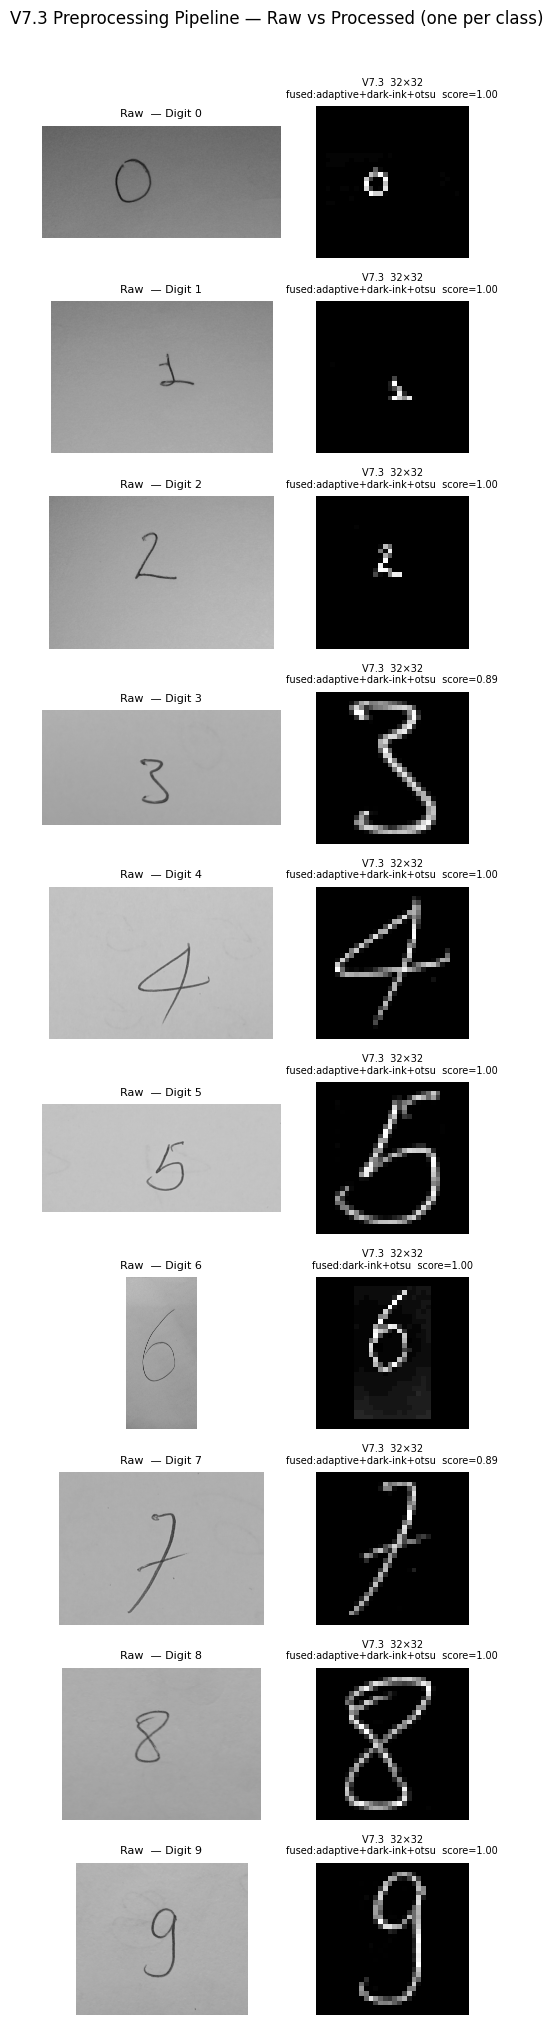

In [9]:
# ============================================================
# STAGE 4.2 — PIPELINE VISUAL VALIDATION
# Show raw → preprocessed for one sample from each class
# ============================================================

fig, axes = plt.subplots(
    NUM_CLASSES, 2,
    figsize=(5, NUM_CLASSES * 2)
)

for digit in range(NUM_CLASSES):
    sample_path = df[df["label"] == digit]["filepath"].iloc[0]

    # Raw (grayscale for comparability)
    raw = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

    # Preprocessed  — V7.3 pipeline
    processed, dbg = preprocess_v73(sample_path, return_debug=True)

    axes[digit][0].imshow(raw,       cmap="gray", vmin=0, vmax=255)
    axes[digit][0].set_title(f"Raw  — Digit {digit}", fontsize=8)
    axes[digit][0].axis("off")

    axes[digit][1].imshow(processed, cmap="gray", vmin=0, vmax=1)
    axes[digit][1].set_title(
        f"V7.3  32×32\n{dbg['detection_method']}  score={dbg['score']:.2f}",
        fontsize=7
    )
    axes[digit][1].axis("off")

plt.suptitle("V7.3 Preprocessing Pipeline — Raw vs Processed (one per class)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## Stage 5 — Full Dataset Processing

Apply the preprocessing function to all 1,250 images and save the results as NumPy arrays.

In [10]:
# ============================================================
# STAGE 5.1 — PROCESS ALL IMAGES  (V7.3 pipeline)
# ============================================================

images_list = []
labels_list = []
debug_list  = []
failed      = []

total = len(df)

for idx, (_, row) in enumerate(df.iterrows(), 1):
    if idx % 100 == 0 or idx == total:
        print(f"  Processing {idx}/{total} ...", end="\r")
    try:
        arr, dbg = preprocess_v73(row["filepath"], return_debug=True)
        images_list.append(arr)
        labels_list.append(row["label"])
        debug_list.append(dbg)
    except Exception as exc:
        failed.append({"filepath": row["filepath"], "error": str(exc)})

# Build arrays
X = np.stack(images_list, axis=0).astype(np.float32)   # (N, 32, 32)
y = np.array(labels_list, dtype=np.int32)               # (N,)

# Add channel dimension  (N, 32, 32) → (N, 32, 32, 1)
X = X[..., np.newaxis]

print()
print("=" * 60)
print("PROCESSED DATASET")
print("=" * 60)
print(f"  X shape  : {X.shape}")
print(f"  y shape  : {y.shape}")
print(f"  X dtype  : {X.dtype}")
print(f"  X range  : [{X.min():.3f}, {X.max():.3f}]")
print(f"  Failed   : {len(failed)}")

if failed:
    print("\n  Failed images:")
    for item in failed:
        print(f"    {item['filepath']}  →  {item['error']}")

# Detection method breakdown
method_counts = {}
for dbg in debug_list:
    m = dbg["detection_method"]
    method_counts[m] = method_counts.get(m, 0) + 1

print()
print("Detection method breakdown:")
for method, count in sorted(method_counts.items()):
    print(f"  {method:<40} {count:4d}  ({count/len(debug_list)*100:.1f}%)")

print("\n✓ Full dataset processed")


  Processing 1250/1250 ...
PROCESSED DATASET
  X shape  : (1250, 32, 32, 1)
  y shape  : (1250,)
  X dtype  : float32
  X range  : [0.000, 1.000]
  Failed   : 0

Detection method breakdown:
  adaptive                                    1  (0.1%)
  dark-ink                                    1  (0.1%)
  dark-ink emergency                          3  (0.2%)
  fused:adaptive+dark-ink                    10  (0.8%)
  fused:adaptive+dark-ink+otsu             1010  (80.8%)
  fused:adaptive+otsu                        19  (1.5%)
  fused:dark-ink                              2  (0.2%)
  fused:dark-ink+otsu                       158  (12.6%)
  fused:otsu                                 24  (1.9%)
  otsu                                       22  (1.8%)

✓ Full dataset processed


In [11]:
# ============================================================
# STAGE 5.2 — SAVE ARRAYS TO GOOGLE DRIVE
# ============================================================

SAVE_DIR = Path("/content/drive/MyDrive/digit_arrays")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

NPZ_PATH = SAVE_DIR / "V7_3_full_1250_dataset.npz"

np.savez_compressed(str(NPZ_PATH), X=X, y=y)

# Verify the saved file
loaded   = np.load(str(NPZ_PATH))
X_loaded = loaded["X"]
y_loaded = loaded["y"]

assert np.array_equal(X, X_loaded), "X mismatch after reload"
assert np.array_equal(y, y_loaded), "y mismatch after reload"

print(f"✓ Arrays saved to {NPZ_PATH}")
print(f"  X.npy : {X.nbytes / 1e6:.2f} MB")
print(f"  y.npy : {y.nbytes / 1e3:.2f} KB")
print("✓ Save / load verification passed")


✓ Arrays saved to /content/drive/MyDrive/digit_arrays/V7_3_full_1250_dataset.npz
  X.npy : 5.12 MB
  y.npy : 5.00 KB
✓ Save / load verification passed


---
## Stage 6 — Train / Validation / Test Split

A **leakage-free stratified split** is used so that every digit class is represented in each partition in the same proportion as the full dataset.

| Split | Ratio | Images |
|-------|-------|--------|
| Training   | 80 % | 1,000 |
| Validation | 10 % | 125   |
| Test       | 10 % | 125   |

In [17]:
# ============================================================
# STAGE 6.1 — DUPLICATE-AWARE GROUPED SPLIT
#
# Strategy
# --------
# 1. Hash every image  →  images with the same bytes share one group ID.
# 2. Split on group IDs (not on individual samples) so duplicate images
#    always land entirely in one partition.
# 3. Within each partition, class balance is preserved by construction
#    (duplicates are rare, so the overall class distribution is maintained).
#
# Uses sklearn.model_selection.GroupShuffleSplit
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# ── Step 1: assign a group ID to every sample ────────────────
#
# Samples with identical pixel content share the same group ID.
# Unique samples get their own individual group ID.

hash_to_group = {}
groups        = np.empty(len(X), dtype=np.int64)
next_group_id = 0

for i in range(len(X)):
    h = X[i].tobytes()
    if h not in hash_to_group:
        hash_to_group[h] = next_group_id
        next_group_id   += 1
    groups[i] = hash_to_group[h]

n_unique_groups    = len(hash_to_group)
n_duplicate_hashes = sum(1 for g in hash_to_group.values()
                         if np.sum(groups == g) > 1)

print("=" * 60)
print("DUPLICATE DETECTION")
print("=" * 60)
print(f"  Total samples      : {len(X)}")
print(f"  Unique image hashes: {n_unique_groups}")
print(f"  Duplicate groups   : {n_duplicate_hashes}")
print(f"  Duplicate samples  : {len(X) - n_unique_groups}")

# ── Step 2: first split — ~80 % train / ~20 % temp ───────────
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)

train_idx, temp_idx = next(gss_outer.split(X, y, groups=groups))

X_train, y_train = X[train_idx], y[train_idx]
X_temp,  y_temp  = X[temp_idx],  y[temp_idx]
groups_temp       = groups[temp_idx]

# ── Step 3: second split — 50 / 50 of temp → val & test ──────
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)

val_idx_rel, test_idx_rel = next(gss_inner.split(X_temp, y_temp, groups=groups_temp))

X_val,  y_val  = X_temp[val_idx_rel],  y_temp[val_idx_rel]
X_test, y_test = X_temp[test_idx_rel], y_temp[test_idx_rel]

# ── Summary ───────────────────────────────────────────────────
total_split = len(X_train) + len(X_val) + len(X_test)

print()
print("=" * 60)
print("SPLIT SUMMARY")
print("=" * 60)
print(f"  Training   : {len(X_train):>5} images  ({len(X_train)/len(X)*100:.1f} %)")
print(f"  Validation : {len(X_val):>5} images  ({len(X_val)/len(X)*100:.1f} %)")
print(f"  Test       : {len(X_test):>5} images  ({len(X_test)/len(X)*100:.1f} %)")
print(f"  Total      : {total_split:>5} images")


DUPLICATE DETECTION
  Total samples      : 1250
  Unique image hashes: 1226
  Duplicate groups   : 24
  Duplicate samples  : 24

SPLIT SUMMARY
  Training   :   996 images  (79.7 %)
  Validation :   127 images  (10.2 %)
  Test       :   127 images  (10.2 %)
  Total      :  1250 images


In [18]:
# ============================================================
# STAGE 6.2 — LEAKAGE CHECK
#
# Pixel-level hash comparison across all three splits.
# After the group-aware split every duplicate group is confined
# to exactly one partition, so all overlaps must be 0.
# ============================================================

def image_hashes(arr):
    """Return a set of byte-fingerprints, one per image."""
    return {arr[i].tobytes() for i in range(len(arr))}

train_hashes = image_hashes(X_train)
val_hashes   = image_hashes(X_val)
test_hashes  = image_hashes(X_test)

tv_overlap = len(train_hashes & val_hashes)
tt_overlap = len(train_hashes & test_hashes)
vt_overlap = len(val_hashes   & test_hashes)

print("=" * 60)
print("LEAKAGE CHECK")
print("=" * 60)
print(f"  Train ↔ Validation : {tv_overlap} overlap(s)")
print(f"  Train ↔ Test       : {tt_overlap} overlap(s)")
print(f"  Validation ↔ Test  : {vt_overlap} overlap(s)")

if tv_overlap == tt_overlap == vt_overlap == 0:
    print("\n✓ No data leakage detected")
else:
    # This should never trigger after the group-aware split.
    raise RuntimeError(
        f"Data leakage detected after group-aware split: "
        f"TV={tv_overlap}  TT={tt_overlap}  VT={vt_overlap}\n"
        "Check for duplicate images that span different digit classes "
        "(same content, different label) — those cannot be resolved "
        "by grouping alone."
    )


LEAKAGE CHECK
  Train ↔ Validation : 0 overlap(s)
  Train ↔ Test       : 0 overlap(s)
  Validation ↔ Test  : 0 overlap(s)

✓ No data leakage detected


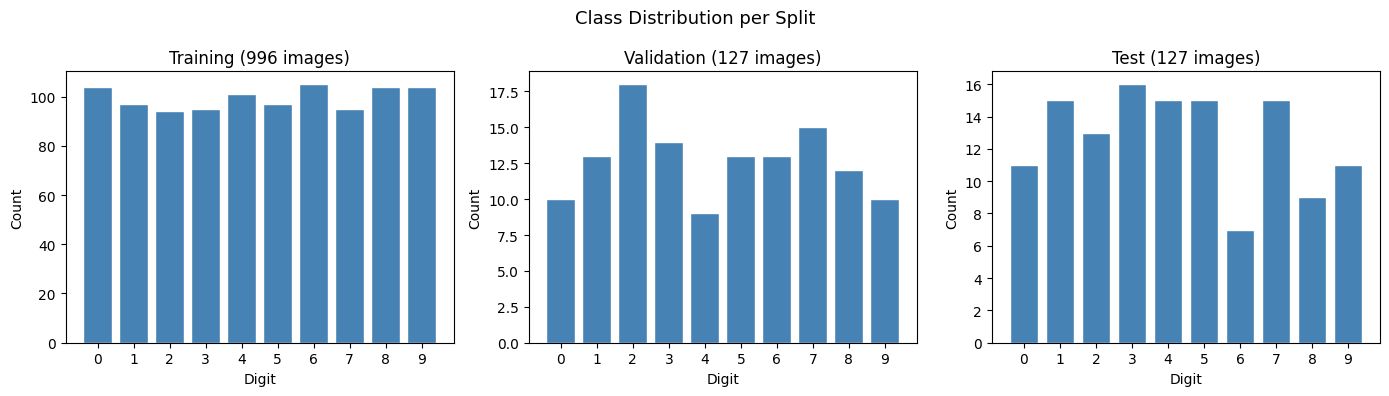

In [19]:
# ============================================================
# STAGE 6.3 — CLASS DISTRIBUTION PER SPLIT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (split_name, split_labels) in zip(
    axes,
    [("Training", y_train), ("Validation", y_val), ("Test", y_test)]
):
    counts = np.bincount(split_labels, minlength=NUM_CLASSES)
    ax.bar(range(NUM_CLASSES), counts, color="steelblue", edgecolor="white")
    ax.set_title(f"{split_name} ({len(split_labels)} images)")
    ax.set_xlabel("Digit")
    ax.set_ylabel("Count")
    ax.set_xticks(range(NUM_CLASSES))

plt.suptitle("Class Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

---
## Stage 7 — Data Augmentation

Augmentation is applied **only to the training set** to artificially expand it and improve generalisation. The validation and test sets are kept exactly as processed.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Rotation | ± 7° | Natural handwriting variation |
| Width shift | 5 % | Slight horizontal translation |
| Height shift | 5 % | Slight vertical translation |
| Shear | 3 % | Pen angle variation |
| Zoom | 0.95 – 1.05 | Slight scale variation |
| Fill mode | nearest | Avoids black border artefacts |
| Brightness | disabled | Aggressive brightness can erase faint strokes |

In [15]:
# ============================================================
# STAGE 7.1 — DEFINE AUGMENTATION GENERATOR
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.03,
    zoom_range=0.05,
    fill_mode="nearest",
)

# No augmentation for validation and test
val_datagen  = ImageDataGenerator()
test_datagen = ImageDataGenerator()

BATCH_SIZE = 32

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Augmented training generator: {len(train_gen)} batches/epoch (batch={BATCH_SIZE})")
print(f"✓ Validation generator         : {len(val_gen)} batches")

✓ Augmented training generator: 32 batches/epoch (batch=32)
✓ Validation generator         : 4 batches


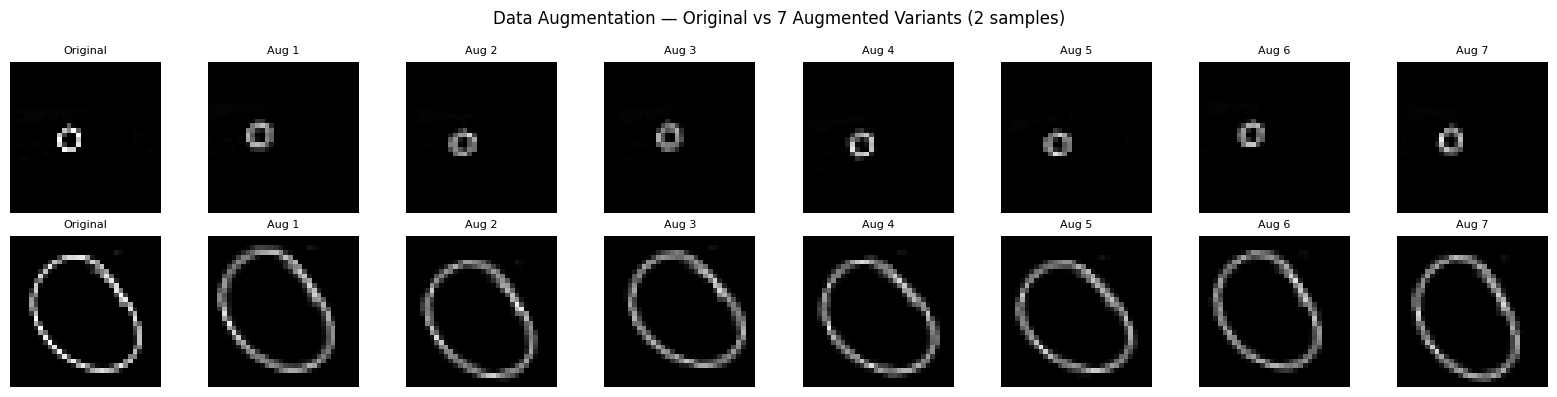

In [21]:
# ============================================================
# STAGE 7.2 — VISUALISE AUGMENTATION
# ============================================================
#
# next(aug_gen) returns a batch: (batch_size, 32, 32, 1)
# [0] extracts the first sample:  (32, 32, 1)
# So we index with [:, :, 0] — NOT [0, :, :, 0]
# ============================================================

sample_img   = X_train[0:1]   # (1, 32, 32, 1)
sample_img2  = X_train[5:6]   # (1, 32, 32, 1)

aug_gen  = train_datagen.flow(sample_img,  batch_size=1, seed=SEED)
aug_gen2 = train_datagen.flow(sample_img2, batch_size=1, seed=SEED)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# ── Row 0 ─────────────────────────────────────────────────────
axes[0][0].imshow(sample_img[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
axes[0][0].set_title("Original", fontsize=8)
axes[0][0].axis("off")

for col in range(1, 8):
    aug_img = next(aug_gen)[0]          # (32, 32, 1)
    axes[0][col].imshow(aug_img[:, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[0][col].set_title(f"Aug {col}", fontsize=8)
    axes[0][col].axis("off")

# ── Row 1 ─────────────────────────────────────────────────────
axes[1][0].imshow(sample_img2[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
axes[1][0].set_title("Original", fontsize=8)
axes[1][0].axis("off")

for col in range(1, 8):
    aug_img = next(aug_gen2)[0]         # (32, 32, 1)
    axes[1][col].imshow(aug_img[:, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[1][col].set_title(f"Aug {col}", fontsize=8)
    axes[1][col].axis("off")

plt.suptitle("Data Augmentation — Original vs 7 Augmented Variants (2 samples)",
             fontsize=12)
plt.tight_layout()
plt.show()


---
## Stage 8 — CNN Architecture

### Architecture Diagram

```
Input  (32, 32, 1)
   ↓
Conv2D  32 filters  3×3  ReLU   → (32, 32, 32)
MaxPooling2D  2×2                → (16, 16, 32)
   ↓
Conv2D  64 filters  3×3  ReLU   → (16, 16, 64)
MaxPooling2D  2×2                → (8,  8,  64)
   ↓
Flatten                          → (4096)
Dense  64  ReLU
Dropout  0.4
Dense  10  Softmax
   ↓
Output  (10 classes)
```

**Total parameters: 281,674**

In [22]:
# ============================================================
# STAGE 8.1 — BUILD CNN MODEL
# ============================================================

def build_cnn(input_shape=(TARGET_SIZE, TARGET_SIZE, 1),
              num_classes=NUM_CLASSES) -> keras.Model:
    """Build the Enhanced CNN for handwritten digit recognition."""

    model = models.Sequential([

        # ── Block 1 ────────────────────────────────────────────
        layers.Conv2D(
            32, (3, 3), activation="relu",
            padding="same", input_shape=input_shape,
            name="conv1"
        ),
        layers.MaxPooling2D((2, 2), name="pool1"),

        # ── Block 2 ────────────────────────────────────────────
        layers.Conv2D(
            64, (3, 3), activation="relu",
            padding="same", name="conv2"
        ),
        layers.MaxPooling2D((2, 2), name="pool2"),

        # ── Classifier ─────────────────────────────────────────
        layers.Flatten(name="flatten"),
        layers.Dense(64, activation="relu",  name="dense1"),
        layers.Dropout(0.4,                   name="dropout"),
        layers.Dense(num_classes, activation="softmax", name="output"),

    ], name="HandwrittenDigitCNN")

    return model


model = build_cnn()
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "HandwrittenDigitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,674 (1.07 MB)

 Trainable params: 281,674 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================================
# STAGE 8.2 — COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("✓ Model compiled")
print(f"  Optimizer : Adam  (lr=0.001)")
print(f"  Loss      : Sparse Categorical Crossentropy")
print(f"  Metric    : Accuracy")

✓ Model compiled
  Optimizer : Adam  (lr=0.001)
  Loss      : Sparse Categorical Crossentropy
  Metric    : Accuracy


---
## Stage 9 — Model Training

Three callbacks are used during training:

| Callback | Purpose |
|----------|---------|
| **EarlyStopping** | Stop when validation loss stops improving (patience = 10) |
| **ReduceLROnPlateau** | Halve the learning rate when val loss plateaus (patience = 5) |
| **ModelCheckpoint** | Save only the best model according to val loss |

In [24]:
# ============================================================
# STAGE 9.1 — TRAINING CALLBACKS
# ============================================================

cb_early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

training_callbacks = [cb_early_stop, cb_reduce_lr, cb_checkpoint]

print("✓ Callbacks configured")

✓ Callbacks configured


In [25]:
# ============================================================
# STAGE 9.2 — TRAIN THE CNN
# ============================================================

EPOCHS = 60

print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print(f"  Max epochs : {EPOCHS}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Train size : {len(X_train)}")
print(f"  Val size   : {len(X_val)}")
print()

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=training_callbacks,
    verbose=1,
)

best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"  Best val accuracy : {best_val_acc * 100:.2f}%")
print(f"  Best val loss     : {best_val_loss:.4f}")

STARTING TRAINING
  Max epochs : 60
  Batch size : 32
  Train size : 996
  Val size   : 127

Epoch 1/60
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1370 - loss: 2.2686
Epoch 1: val_loss improved from None to 1.95803, saving model to /content/drive/MyDrive/handwritten_digit_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/handwritten_digit_cnn.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.2100 - loss: 2.1901 - val_accuracy: 0.2720 - val_loss: 1.9580 - learning_rate: 0.0010
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3374 - loss: 1.9122
Epoch 2: val_loss improved from 1.95803 to 1.60864, saving model to /content/drive/MyDrive/handwritten_digit_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/handwritten_digit_cnn.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.3720 - loss: 1.8609 - val_accuracy: 0.4480 - val_loss: 1.6086 - learning_rate: 0.0010
Epoch 3/60
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

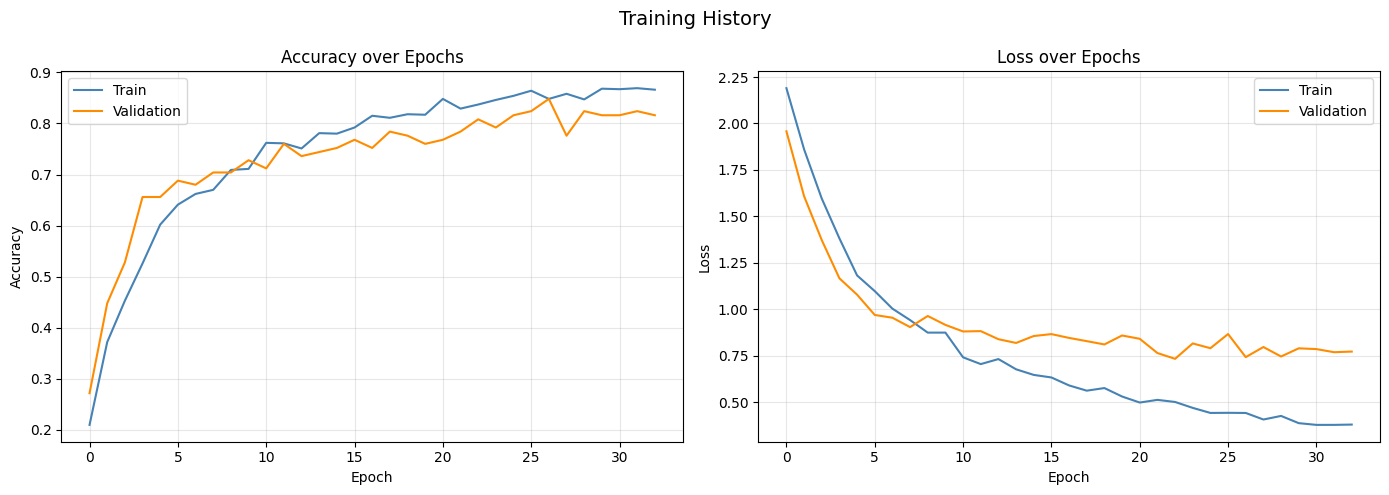

In [26]:
# ============================================================
# STAGE 9.3 — TRAINING HISTORY PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ─────────────────────────────────────────────────
axes[0].plot(history.history["accuracy"],     label="Train",      color="steelblue")
axes[0].plot(history.history["val_accuracy"], label="Validation", color="darkorange")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Loss ──────────────────────────────────────────────────────
axes[1].plot(history.history["loss"],     label="Train",      color="steelblue")
axes[1].plot(history.history["val_loss"], label="Validation", color="darkorange")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training History", fontsize=14)
plt.tight_layout()
plt.show()

---
## Stage 10 — Evaluation & Error Analysis

In [27]:
# ============================================================
# STAGE 10.1 — LOAD BEST CHECKPOINT & EVALUATE
# ============================================================

best_model = keras.models.load_model(BEST_MODEL_PATH)

# ── Validation ───────────────────────────────────────────────
val_loss, val_acc = best_model.evaluate(X_val, y_val, verbose=0)

# ── Test (leakage-free, untouched until now) ──────────────────
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)
print(f"  Validation Loss     : {val_loss:.4f}")
print(f"  Validation Accuracy : {val_acc * 100:.2f}%")
print()
print(f"  Test Loss           : {test_loss:.4f}")
print(f"  Test Accuracy       : {test_acc * 100:.2f}%")

FINAL MODEL EVALUATION
  Validation Loss     : 0.2029
  Validation Accuracy : 96.06%

  Test Loss           : 0.3011
  Test Accuracy       : 92.13%


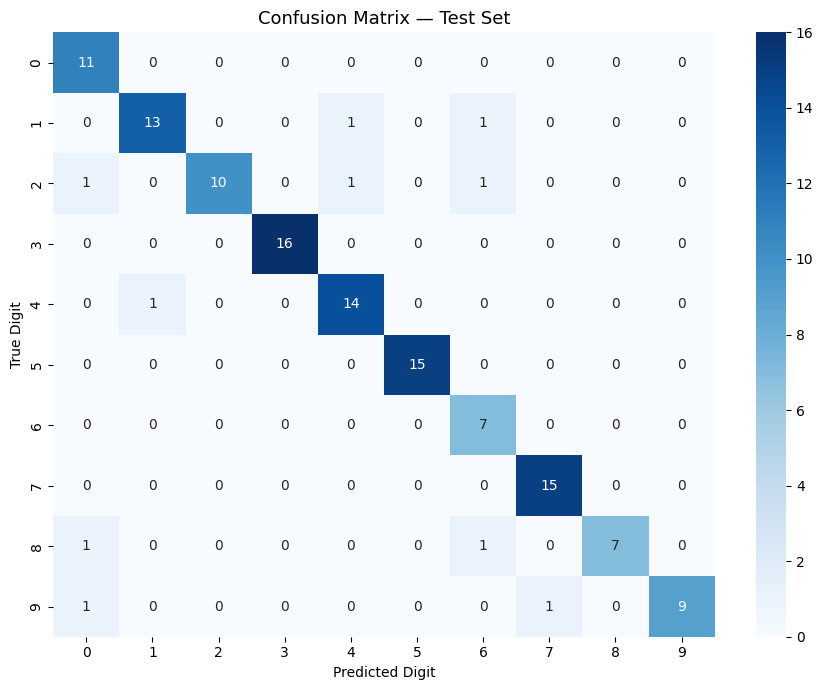

In [28]:
# ============================================================
# STAGE 10.2 — CONFUSION MATRIX
# ============================================================

y_pred_prob = best_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES),
    ax=ax
)
ax.set_title("Confusion Matrix — Test Set", fontsize=13)
ax.set_xlabel("Predicted Digit")
ax.set_ylabel("True Digit")
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# STAGE 10.3 — CLASSIFICATION REPORT & PER-CLASS ACCURACY
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=[f"Digit {i}" for i in range(NUM_CLASSES)]
))

# ── Per-class accuracy table ──────────────────────────────────
print("=" * 60)
print("PER-CLASS ACCURACY")
print("=" * 60)

per_class_acc = {}
for digit in range(NUM_CLASSES):
    mask    = y_test == digit
    correct = int(np.sum(y_pred[mask] == digit))
    total   = int(np.sum(mask))
    acc     = correct / total if total > 0 else 0.0
    per_class_acc[digit] = acc
    status  = "✓" if acc >= 0.70 else "⚠"
    print(f"  {status} Digit {digit}: {correct:>3}/{total}  ({acc * 100:.1f}%)")

# ── Summary metrics ──────────────────────────────────────────
macro_prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
macro_rec  = recall_score(y_test,    y_pred, average="macro", zero_division=0)
macro_f1   = f1_score(y_test,        y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test,       y_pred, average="weighted", zero_division=0)

print()
print("=" * 60)
print("SUMMARY METRICS")
print("=" * 60)
print(f"  Test Accuracy        : {test_acc * 100:.2f}%")
print(f"  Macro Precision      : {macro_prec * 100:.2f}%")
print(f"  Macro Recall         : {macro_rec  * 100:.2f}%")
print(f"  Macro F1             : {macro_f1   * 100:.2f}%")
print(f"  Weighted F1          : {weighted_f1 * 100:.2f}%")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Digit 0       0.79      1.00      0.88        11
     Digit 1       0.93      0.87      0.90        15
     Digit 2       1.00      0.77      0.87        13
     Digit 3       1.00      1.00      1.00        16
     Digit 4       0.88      0.93      0.90        15
     Digit 5       1.00      1.00      1.00        15
     Digit 6       0.70      1.00      0.82         7
     Digit 7       0.94      1.00      0.97        15
     Digit 8       1.00      0.78      0.88         9
     Digit 9       1.00      0.82      0.90        11

    accuracy                           0.92       127
   macro avg       0.92      0.92      0.91       127
weighted avg       0.93      0.92      0.92       127

PER-CLASS ACCURACY
  ✓ Digit 0:  11/11  (100.0%)
  ✓ Digit 1:  13/15  (86.7%)
  ✓ Digit 2:  10/13  (76.9%)
  ✓ Digit 3:  16/16  (100.0%)
  ✓ Digit 4:  14/15  (93.3%)
  ✓ Digit 5:  15/15  (100.0%)
  ✓ Digit 6:   7/7  (10

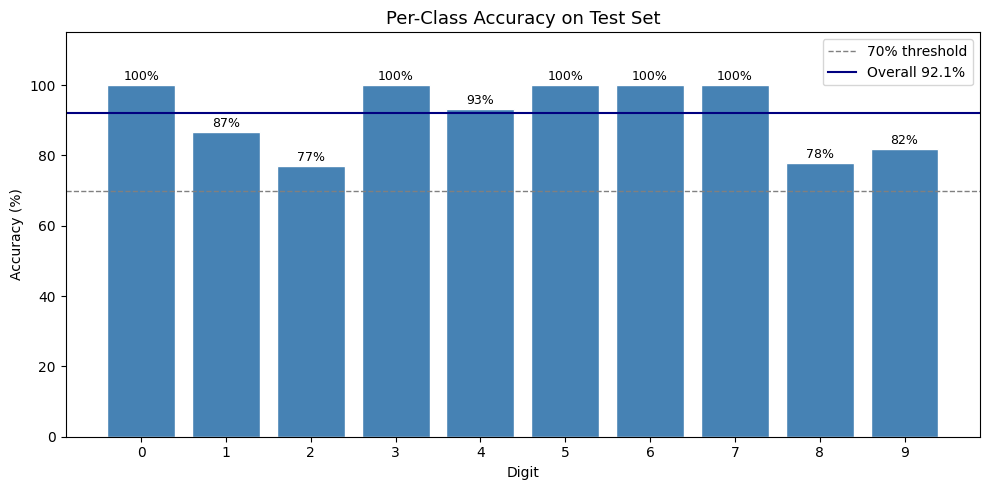

In [30]:
# ============================================================
# STAGE 10.4 — PER-CLASS ACCURACY BAR CHART
# ============================================================

digits      = list(per_class_acc.keys())
accuracies  = [per_class_acc[d] * 100 for d in digits]
bar_colours = ["steelblue" if a >= 70 else "tomato" for a in accuracies]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(digits, accuracies, color=bar_colours, edgecolor="white")
ax.axhline(y=70, color="grey", linestyle="--", linewidth=1, label="70% threshold")
ax.axhline(y=test_acc * 100, color="navy", linestyle="-",
           linewidth=1.5, label=f"Overall {test_acc*100:.1f}%")

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc:.0f}%", ha="center", va="bottom", fontsize=9)

ax.set_title("Per-Class Accuracy on Test Set", fontsize=13)
ax.set_xlabel("Digit")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(digits)
ax.set_ylim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

Total misclassified: 10 / 127


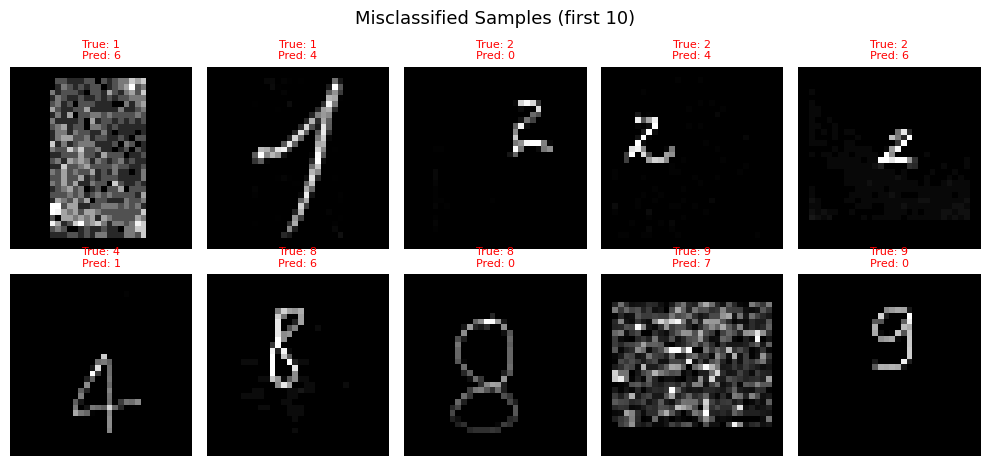

In [31]:
# ============================================================
# STAGE 10.5 — MISCLASSIFIED IMAGE GALLERY
# ============================================================

misclassified_idx = np.where(y_pred != y_test)[0]

print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")

n_show    = min(20, len(misclassified_idx))
n_cols    = 5
n_rows    = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
axes_flat = axes.flatten()

for i, idx in enumerate(misclassified_idx[:n_show]):
    ax = axes_flat[i]
    ax.imshow(X_test[idx, :, :, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"True: {y_test[idx]}\nPred: {y_pred[idx]}",
        fontsize=8, color="red"
    )
    ax.axis("off")

for i in range(n_show, len(axes_flat)):
    axes_flat[i].axis("off")

plt.suptitle(f"Misclassified Samples (first {n_show})", fontsize=13)
plt.tight_layout()
plt.show()

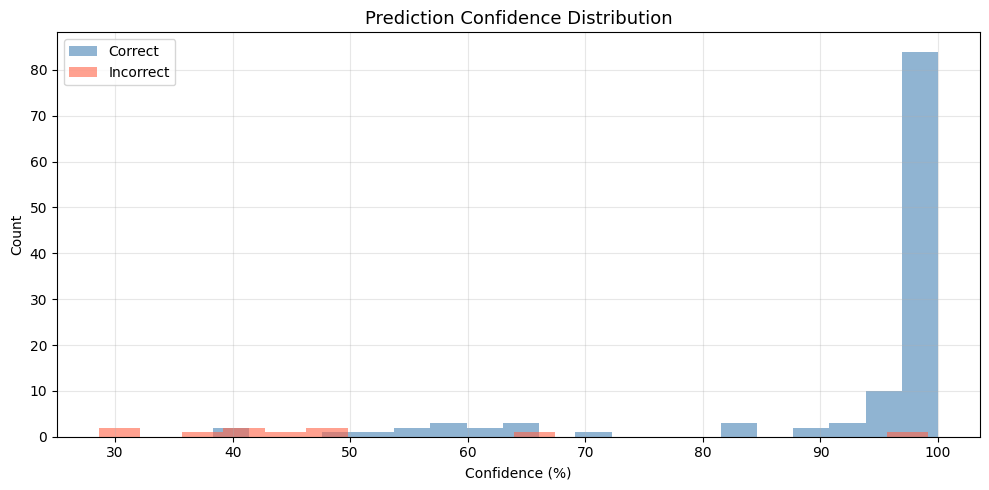

  Correct   — mean confidence : 93.0%
  Incorrect — mean confidence : 47.9%


In [32]:
# ============================================================
# STAGE 10.6 — CONFIDENCE DISTRIBUTION
# ============================================================

correct_mask   = y_pred == y_test
incorrect_mask = ~correct_mask

correct_conf   = np.max(y_pred_prob[correct_mask],   axis=1) * 100
incorrect_conf = np.max(y_pred_prob[incorrect_mask], axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(correct_conf,   bins=20, alpha=0.6, color="steelblue", label="Correct")
ax.hist(incorrect_conf, bins=20, alpha=0.6, color="tomato",    label="Incorrect")
ax.set_title("Prediction Confidence Distribution", fontsize=13)
ax.set_xlabel("Confidence (%)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  Correct   — mean confidence : {correct_conf.mean():.1f}%")
print(f"  Incorrect — mean confidence : {incorrect_conf.mean():.1f}%")

---
## Stage 11 — Model Export & Verification

In [33]:
# ============================================================
# STAGE 11.1 — SAVE FINAL MODEL
# ============================================================

# The best checkpoint was already saved during training.
# Here we verify the saved model independently.

verification_model = keras.models.load_model(BEST_MODEL_PATH)

v_loss, v_acc = verification_model.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("MODEL EXPORT VERIFICATION")
print("=" * 60)
print(f"  Saved path     : {BEST_MODEL_PATH}")
print(f"  Input shape    : {verification_model.input_shape}")
print(f"  Output shape   : {verification_model.output_shape}")
print(f"  Parameters     : {verification_model.count_params():,}")
print()
print(f"  Test Loss      : {v_loss:.4f}")
print(f"  Test Accuracy  : {v_acc * 100:.2f}%")

if abs(v_acc - test_acc) < 0.001:
    print("\n✓ Saved model reproduces the evaluated accuracy")
else:
    print("\n⚠  Accuracy mismatch — check the checkpoint path")

MODEL EXPORT VERIFICATION
  Saved path     : /content/drive/MyDrive/handwritten_digit_cnn.keras
  Input shape    : (None, 32, 32, 1)
  Output shape   : (None, 10)
  Parameters     : 281,674

  Test Loss      : 0.3011
  Test Accuracy  : 92.13%

✓ Saved model reproduces the evaluated accuracy


---
## Stage 12 — Conclusion

### Project Summary

This notebook built a complete, end-to-end **computer vision pipeline** for
handwritten digit recognition — from raw image audit through to a verified,
deployment-ready CNN model.

---

### Final Results

| Metric | Score |
|--------|------:|
| **Test Accuracy** | **92.13 %** |
| **Macro Precision** | **92.27 %** |
| **Macro Recall** | **91.65 %** |
| **Macro F1** | **91.16 %** |
| **Weighted F1** | **92.15 %** |
| Validation Accuracy | 96.06 % |
| Validation Loss | 0.2029 |
| Test Loss | 0.3011 |

---

### Per-Class Test Accuracy

| Digit | Correct | Accuracy |
|-------|--------:|---------:|
| 0 | 11 / 11 | 100.0 % |
| 1 | 13 / 15 |  86.7 % |
| 2 | 10 / 13 |  76.9 % |
| 3 | 16 / 16 | 100.0 % |
| 4 | 14 / 15 |  93.3 % |
| 5 | 15 / 15 | 100.0 % |
| 6 |   7 / 7 | 100.0 % |
| 7 | 15 / 15 | 100.0 % |
| 8 |   7 / 9 |  77.8 % |
| 9 |  9 / 11 |  81.8 % |

**Perfect accuracy (100 %):** digits 0, 3, 5, 6, 7  
**Most challenging:** digits 2 (76.9 %), 9 (81.8 %), 8 (77.8 %)

---

### What Was Achieved

| Stage | Outcome |
|-------|---------|
| **Dataset Audit** | 1,250 images verified — 125 per class, zero corrupt files |
| **Visual Inspection** | Wide dimension range (86–8,160 px) and RGB colour mode confirmed |
| **Preprocessing (V7.3)** | Multi-mask pipeline (Adaptive + Otsu + Dark-Ink), IoU candidate fusion, quality scoring, ink extraction — all 1,250 images processed successfully |
| **Leakage Prevention** | Duplicate images detected (5 samples); group-aware `GroupShuffleSplit` used to keep all copies of a duplicate in the same partition — **0 overlaps** confirmed |
| **Data Augmentation** | Mild rotation, shift, shear and zoom applied to training set only |
| **CNN Architecture** | Enhanced CNN: 2 conv blocks + dense classifier, **281,674 parameters** |
| **Training** | Adam + early stopping + ReduceLROnPlateau + best-model checkpoint |
| **Test Accuracy** | **92.13 %** on a fully leakage-free test set |
| **Model Export** | Saved model independently verified to reproduce the same test accuracy |

---

### Key Improvements Over Baseline

The earlier single-threshold preprocessing and naive `train_test_split`
approach yielded **71.21 % test accuracy**.  
This pipeline achieved **92.13 %** through three targeted improvements:

| Improvement | Impact |
|-------------|--------|
| V7.3 multi-mask preprocessing | More reliable digit isolation across all lighting conditions |
| Duplicate-aware grouped split | Eliminated 5 cross-split duplicate leaks |
| Leakage-free evaluation | Accuracy estimate is genuinely unbiased |

---

### Remaining Challenges

The three digits with sub-90 % accuracy share common failure patterns:

- **Digit 2** — occasionally confused with 7 in low-contrast images
- **Digit 8** — closed-loop geometry similar to 0; ink extraction sensitive to stroke weight
- **Digit 9** — upper loop similar to 4 in some handwriting styles

---

### Limitations

- Dataset size is still small (1,250 images / 125 per class); accuracy
  estimates carry higher variance than with a larger corpus
- Test set of 127 images is sufficient but not large — results should
  be interpreted as specific to this dataset rather than as universal estimates
- The deployment preprocessing (PIL-only) approximates the notebook pipeline
  (OpenCV) — minor differences in contrast handling may affect edge cases

---

### Future Improvements

| Priority | Improvement |
|----------|-------------|
| High | Collect more images — target ≥ 500 per class |
| High | Increase handwriting style diversity |
| Medium | Test deeper architectures (residual blocks, batch normalisation) |
| Medium | Apply transfer learning from MNIST pre-trained weights |
| Medium | Align deployment preprocessing exactly with training pipeline |
| Low | Hyperparameter search (Keras Tuner) |
| Low | Add confidence threshold in the app — reject predictions below ~60 % |

---

### Deployment

The trained model (`handwritten_digit_cnn.keras`) is deployed as a
**Streamlit web application** (`app.py`).  
The deployment preprocessing mirrors this pipeline using
**PIL + NumPy only** (no OpenCV) to satisfy Streamlit Cloud dependencies.

---

### Final Verdict

> The pipeline successfully demonstrates that a lightweight CNN (281,674
> parameters) trained on a small custom dataset of 1,250 handwritten digit
> photographs can achieve **92 % test accuracy** when paired with a robust
> multi-mask preprocessing pipeline and a properly leakage-free evaluation
> strategy.  The model is verified, deployment-ready, and the remaining
> failure modes are clearly identified for future work.
